In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from utils.plot_style import set_plot_style
set_plot_style()

In [67]:
lam = 1064e-9

In [ ]:
def M_free(L):
    return np.array([[1, L],
                     [0, 1]])

def M_sph_mirror(R):
    f = R/2
    return np.array([[1, 0],
                     [-1/f, 1]])

In [6]:
def stability_condition(A, D):
    return abs((A + D)/2) < 1

# Flat mirror and curved mirror (R)

In [31]:
R = 100e-3          # radius of curvature of curved mirror [m]
L_array = np.linspace(0.01, 0.800, 800)   # scan cavity length (m)

In [45]:
w_target = 40e-6   # m
tol = 0.1 * w_target # 10% tolerance

w0_list, z0_list = [], []
w_target_list, z_target_list = [], []

for L in L_array:

    M = M_sph_mirror(np.inf) @ M_free(L) @ M_sph_mirror(R) @ M_free(L)

    A, B, C, D = M.ravel()

    stable = abs((A + D)/2) < 1

    if stable:

        q_roots = np.roots([C, D - A, -B])
        q = q_roots[np.imag(q_roots) > 0][0]

        z_values = np.linspace(0, L, 1000)
        q_values = q + z_values

        inv_q_values = 1 / q_values

        w_values = np.sqrt(
            - lam / (np.pi * np.imag(inv_q_values))
        )

        # actual cavity waist
        i0 = np.argmin(w_values)

        w0_list.append(w_values[i0] * 1e6)   # µm
        z0_list.append(z_values[i0] * 100)   # cm
        
        # target waist crossing
        diff = w_values - w_target
        idx = np.where(np.diff(np.sign(diff)) != 0)[0]

        if len(idx) > 0:
            i = idx[0]

            z1, z2 = z_values[i], z_values[i+1]
            w1, w2 = w_values[i], w_values[i+1]

            z_cross = z1 + (w_target - w1) * (z2 - z1) / (w2 - w1)

            w_target_list.append(w_target * 1e6)  # microns
            z_target_list.append(z_cross * 1e3)  # mm

        else:
            w_target_list.append(np.nan)
            z_target_list.append(np.nan)


    else:
        w0_list.append(np.nan)
        z0_list.append(np.nan)
        w_target_list.append(np.nan)
        z_target_list.append(np.nan)

In [46]:
# Actual cavity waist (but it is on the flat mirror)
w0_arr = np.array(w0_list)
z0_arr = np.array(z0_list)
# Waist we are looking for
w_target_arr = np.array(w_target_list)
z_target_arr = np.array(z_target_list)
print("Non nan value of z: ", z_target_arr[~np.isnan(z_target_arr)])


Non nan value of z:  [2.77333871]


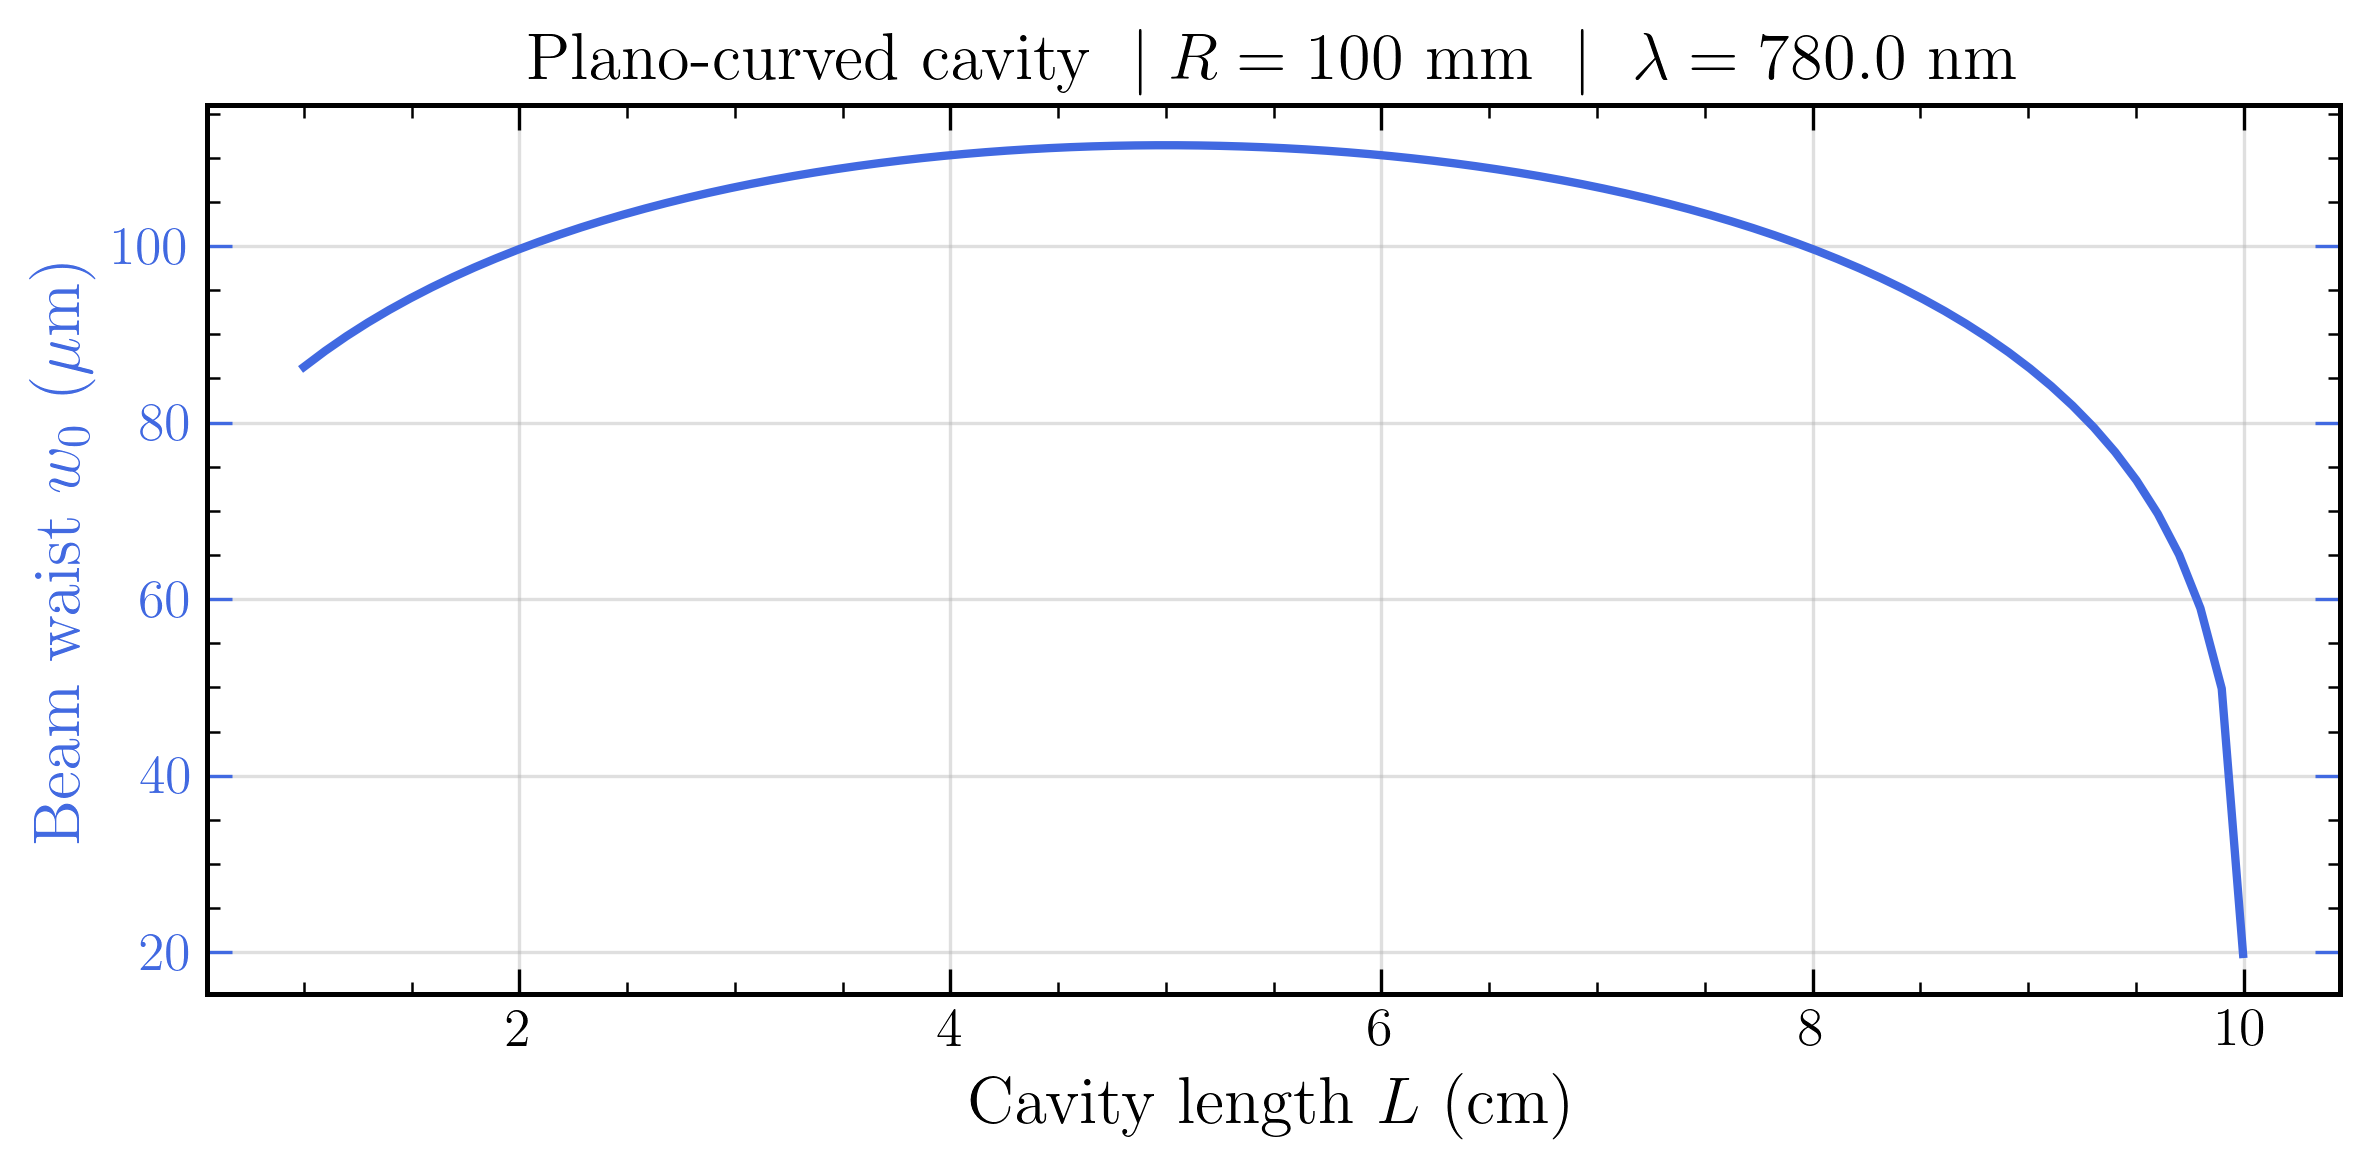

In [47]:
# Waist of cavity VS length
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(
    L_array * 100,
    w0_arr,
    color='royalblue',
    lw=2,
    label=r'Waist $w_0$ ($\mu$m)'
)

# ax1.axhline(
#     w_target * 1e6,
#     color='tomato',
#     ls='--',
#     lw=1.5,
#     label=rf'Target waist = {w_target*1e6:.0f} $\mu$m'
# )

ax1.set_xlabel(r'Cavity length $L$ (cm)')

ax1.set_ylabel(
    r'Beam waist $w_0$ ($\mu$m)',
    color='royalblue'
)

ax1.set_title(
    r'Plano-curved cavity $\;|\;$'
    rf'$R = {R*1e3:.0f}$ mm'
    rf' $\;|\;$ $\lambda = {lam*1e9}$ nm'
)

ax1.tick_params(axis='y', colors='royalblue')

# ax1.legend(framealpha=0.9)

ax1.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [48]:
# indices where target waist exists
valid_idx = np.where(~np.isnan(z_target_arr))[0]

print(f"{len(valid_idx)} valid solutions found for target waist {w_target*1e6} µm\n")

for i in valid_idx:

    L_val = L_array[i] * 1e3     # mm
    z_val = z_target_arr[i]       # already in cm

    print(
        f"L = {L_val:.3f} cm   |   "
        f"z_target = {z_val:.3f} mm"
    )

1 valid solutions found for target waist 40.0 µm

L = 99.975 cm   |   z_target = 2.773 mm


### Explore for fixed length where desired waist lies

In [49]:
# Fixed cavity length
L_fixed = 14e-2      # 10 cm
w_target = 40e-6     # 40 µm

In [50]:
# compute waist for this fixed L
M = M_sph_mirror(np.inf) @ M_free(L_fixed) @ M_sph_mirror(R) @ M_free(L_fixed)

A, B, C, D = M.ravel()
stable = abs((A + D)/2) < 1

if stable:
    q_roots = np.roots([C, D - A, -B])
    q = q_roots[np.imag(q_roots) > 0][0]

    z_values = np.linspace(0, L_fixed, 1000)
    q_values = q + z_values

    w_values = np.sqrt(
        - lam / (np.pi * np.imag(1 / q_values))
    )

    w0 = np.min(w_values)
    z0 = z_values[np.argmin(w_values)]

    print(f"For L = {L_fixed*100:.2f} cm:")
    print(f"w0 = {w0*1e6:.2f} µm")
    print(f"z0 = {z0*100:.2f} cm from flat mirror")

else:
    print("Cavity is unstable for this L")

Cavity is unstable for this L


In [112]:
# find positions inside the cavity where w(z) = target
diff = w_values - w_target

idx = np.where(np.diff(np.sign(diff)) != 0)[0]

print(f"\nPositions where w(z) ≈ {w_target*1e6:.3f} µm:")

for i in idx:
    z1, z2 = z_values[i], z_values[i+1]
    w1, w2 = w_values[i], w_values[i+1]

    z_cross = z1 + (w_target - w1) * (z2 - z1) / (w2 - w1)

    if not np.isnan(z_cross):
        print(f"z = {z_cross*100:.2f} cm from flat mirror")


Positions where w(z) ≈ 40.000 µm:


# Two curved mirrors $R_1$ and $R_2$

In [120]:
lam = 1064e-9
n = 1.816
d = 10e-3
R1 = 250e-3    # [m]
R2 = 250e-3    # [m]

L_array = np.linspace(0.01, 0.09, 500)

In [121]:
w0_list = []
z0_list = []
stable_list = []

for L in L_array:

    L_air = L - d
    L1 = L_air / 2
    L2 = L_air / 2

    M = (
        M_sph_mirror(R1)
        @ M_free(L1)
        @ M_free(d / n)
        @ M_free(L2)
        @ M_sph_mirror(R2)
        @ M_free(L2)
        @ M_free(d / n)
        @ M_free(L1)
    )

    # M = (
    #     M_sph_mirror(R1)
    #     @ M_free(L)
    #     @ M_sph_mirror(R2)
    #     @ M_free(L)
    # )

    A, B, C, D = M.ravel()

    stable = stability_condition(A, D)
    stable_list.append(stable)

    if stable:

        q_roots = np.roots([C, D - A, -B])
        q = q_roots[np.imag(q_roots) > 0][0]

        # propagate from M1 to M2
        z_air_1 = np.linspace(0, L1, 400)
        q_air_1 = q + z_air_1

        z_cr = np.linspace(0, d, 300)
        q_cr = q_air_1[-1] + z_cr / n

        z_air_2 = np.linspace(0, L2, 400)
        q_air_2 = q_cr[-1] + z_air_2

        z = np.concatenate([
            z_air_1,
            L1 + z_cr,
            L1 + d + z_air_2
        ])

        qz = np.concatenate([
            q_air_1,
            q_cr,
            q_air_2
        ])

        inv_qz = 1 / qz
        wz = np.sqrt(-lam / (np.pi * np.imag(inv_qz)))

        i0 = np.argmin(wz)

        w0_list.append(wz[i0] * 1e6)   # um
        z0_list.append(z[i0] * 100)    # cm from M1

    else:
        w0_list.append(np.nan)
        z0_list.append(np.nan)

w0_arr = np.array(w0_list)
z0_arr = np.array(z0_list)

In [122]:
w0_arr = np.array(w0_list)
z0_arr = np.array(z0_list)

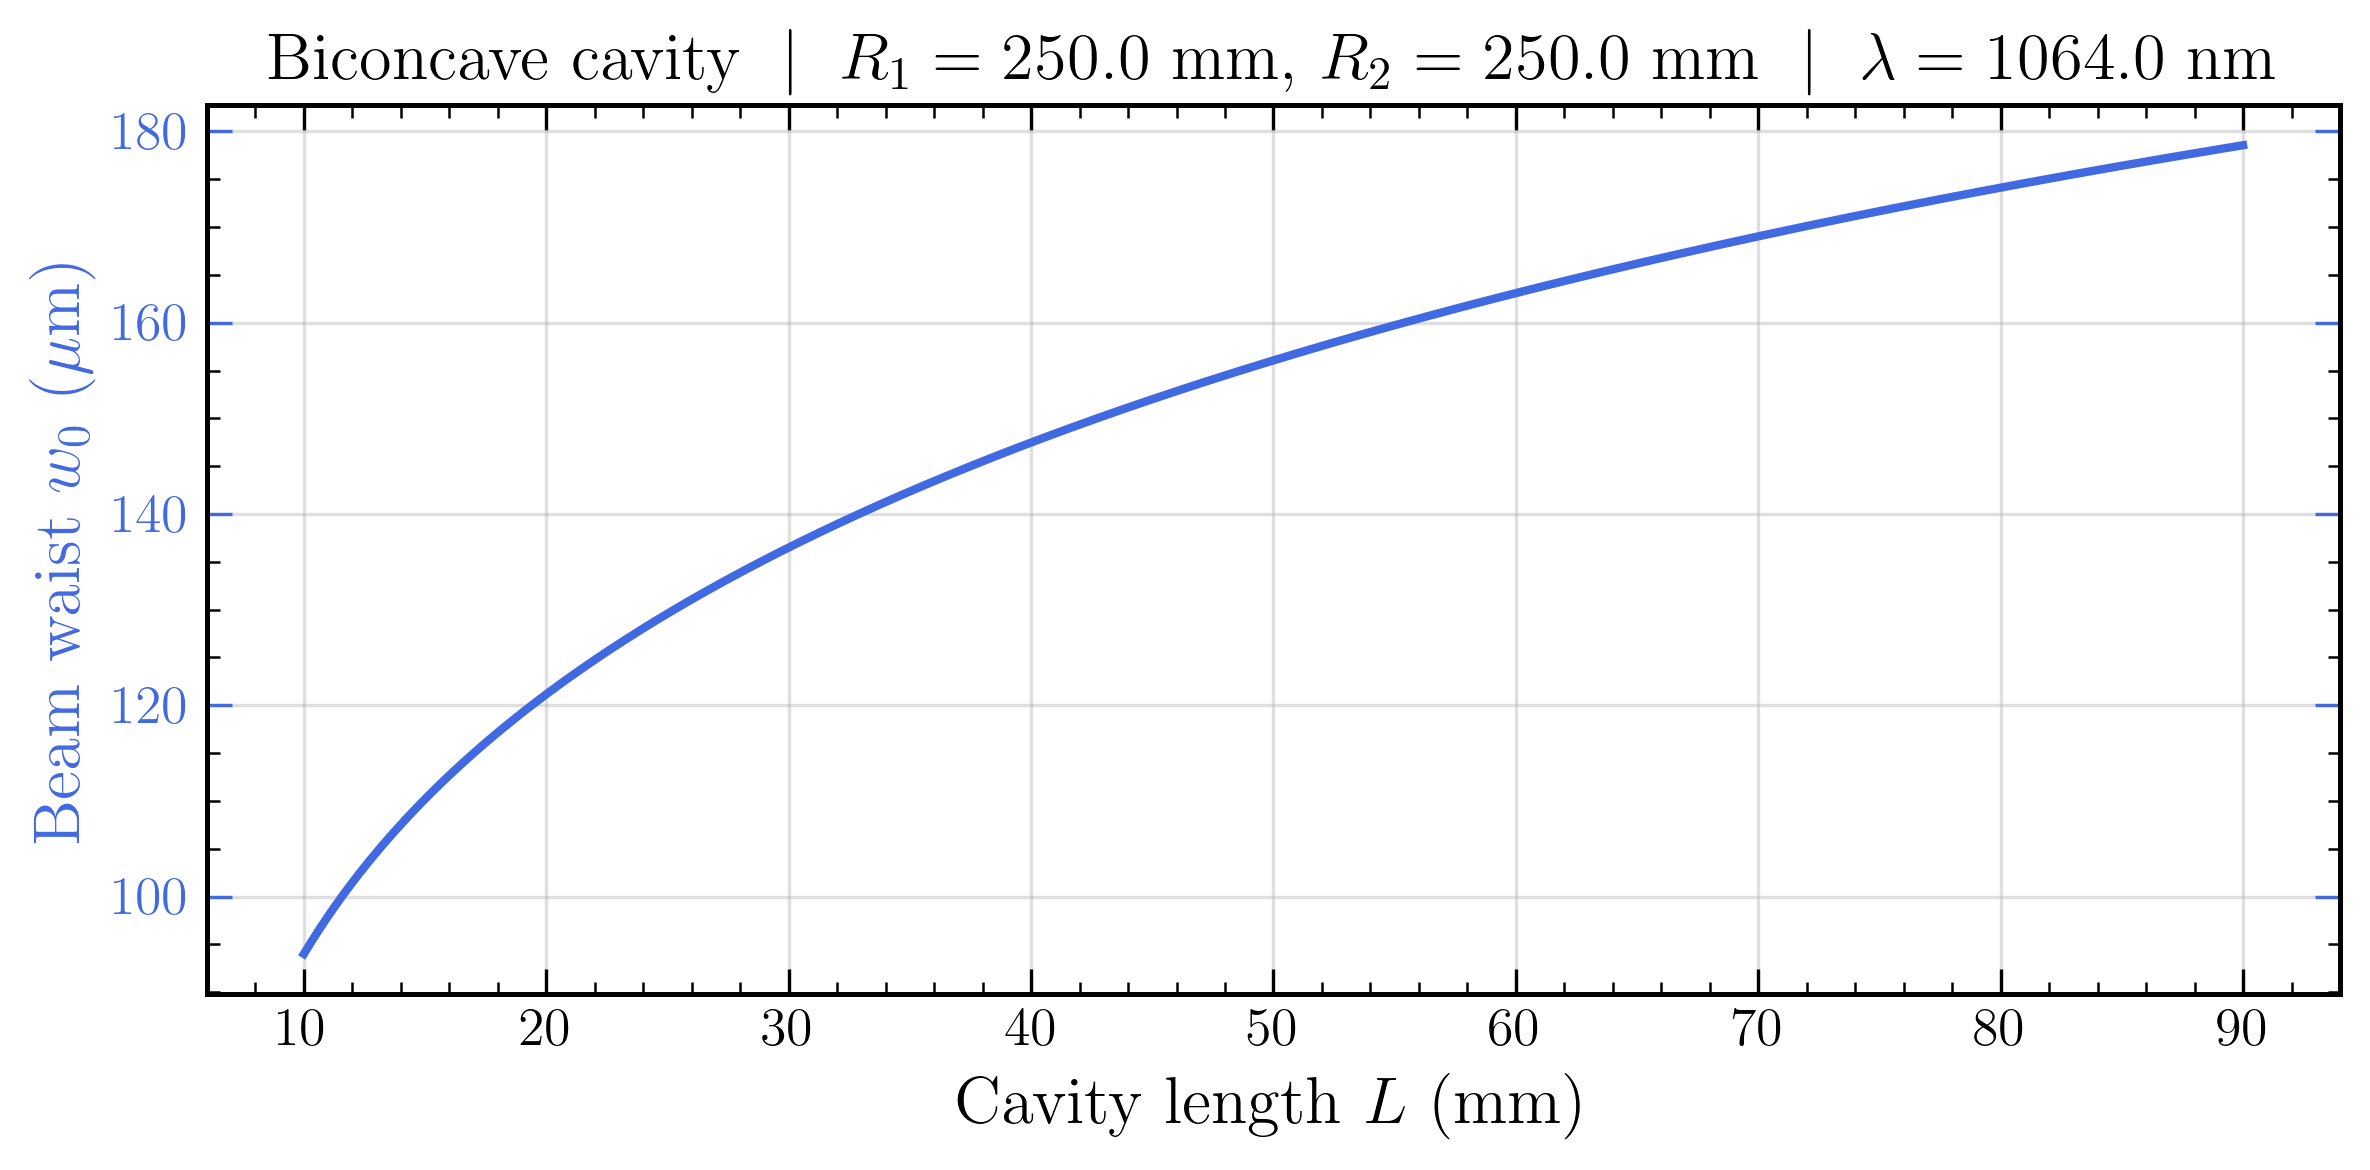

In [123]:
fig, ax1 = plt.subplots(figsize=(8, 4))
# ax2 = ax1.twinx()

ax1.plot(L_array*1e3, w0_arr, color="royalblue", lw=2,
         label=r"Waist $w_0$ ($\mu$m)")

# ax2.plot(L_array*100, z0_arr, color="tomato", lw=2, ls="--",
#          label=r"Waist position $z_0$ (cm from $M_1$)")

ax1.set_xlabel(r"Cavity length $L$ (mm)")
ax1.set_ylabel(r"Beam waist $w_0$ ($\mu$m)", color="royalblue")
# ax2.set_ylabel(r"Waist position $z_0$ (cm from $M_1$)", color="tomato")

ax1.set_title(
    r"Biconcave cavity $\;|\;$"
    rf" $R_1={R1*1e3:.1f}$ mm, $R_2={R2*1e3:.1f}$ mm"
    rf" $\;|\;$ $\lambda={lam*1e9}$ nm"
)

ax1.tick_params(axis="y", colors="royalblue")
# ax2.tick_params(axis="y", colors="tomato")

# lines1, lab1 = ax1.get_legend_handles_labels()
# lines2, lab2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, lab1 + lab2, loc="lower right", framealpha=0.9)

ax1.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# check one value
L_test = 50e-3

idx = np.argmin(abs(L_array - L_test))
print(f"L = {L_array[idx]*100:.2f} cm")
print(f"w0 = {w0_arr[idx]:.2f} um")
print(f"z0 = {z0_arr[idx]:.2f} cm from M1")

L = 4.50 cm
w0 = 50.42 um
z0 = 2.25 cm from M1


## Finesse

### Linear

In [ ]:
# cavity length
L = 0.10   # m

# mirror reflectivities
R1 = 0.99
R2 = 0.89

# effective reflectivity
R = R1 * R2

# finesse
F = np.pi * np.sqrt(R) / (1 - R)

# cavity numbers
c = 3e8
FSR = c / (2*L)
linewidth = FSR / F

print("Finesse =", F)
print("FSR =", FSR/1e6, "MHz")
print("Linewidth =", linewidth/1e6, "MHz")

Finesse = 24.801652526401504
FSR = 1500.0 MHz
Linewidth = 60.4798409462128 MHz


### Bow-tie

In [78]:
# round-trip length
L = 0.494   # m

# mirror reflectivities
R1 = 0.95
R2 = 0.95
R3 = 0.99
R4 = 0.99

# total round-trip reflectivity
R = R1 * R2 * R3 * R4

# finesse
F = np.pi * np.sqrt(R) / (1 - R)

# cavity numbers
c = 3e8
FSR = c / L
linewidth = FSR / F

print("Finesse =", F)
print("FSR =", FSR/1e6, "MHz")
print("Linewidth =", linewidth/1e6, "MHz")

Finesse = 25.59045806613299
FSR = 607.2874493927126 MHz
Linewidth = 23.731011294260927 MHz
